# Hyperparameter Optimization Patterns with PyTorch, Ray, and Optuna

---

## 1. Introduction

### Goal of This Notebook

This notebook explores different strategies for **hyperparameter tuning** on a supervised learning problem using PyTorch. We will cover:

- **Manual hyperparameter search** fundamentals
- **Learning rate scheduling** for faster convergence
- **Early stopping** to prevent overfitting
- **Optuna** for flexible, define-by-run optimization
- **Ray Tune** for scalable distributed tuning
- **Hybrid approaches** combining Ray + Optuna
- **Weights & Biases (WandB)** for experiment tracking and visualization

We'll use a simple "toy" dataset to ensure everything runs quickly on modest hardware.

### Tools Overview

| Tool | Purpose |
|------|--------|
| **PyTorch** | Deep learning framework for building and training neural networks |
| **Optuna** | Define-by-run hyperparameter optimization framework with pruning support |
| **Ray Tune** | Scalable framework for distributed experiment execution and tuning |
| **Weights & Biases (WandB)** | Experiment tracking, visualization, and collaboration platform |

#### Why These Tools?

- **Optuna**: Offers flexibility with dynamic search spaces constructed at runtime. Great for complex, conditional hyperparameter relationships.
- **Ray Tune**: Excels at scaling experiments across multiple GPUs/machines with resource-aware scheduling.
- **WandB**: Provides beautiful dashboards for comparing runs, parallel coordinate plots, and team collaboration.

---

## 2. Setup and Prerequisites

### Install Required Libraries

Run the cell below to install all necessary packages. If you already have them installed, you can skip this cell.

In [1]:
# Install required libraries (uncomment if needed)
# !pip install torch torchvision ray[tune] optuna wandb optuna-integration matplotlib

In [2]:
# Core imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

# Data and visualization
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Hyperparameter optimization
import optuna
from optuna.trial import TrialState

# Ray Tune (API updated for Ray 2.x)
import ray
from ray import tune
from ray.tune import RunConfig  # Import from ray.tune for Tuner
from ray.tune.schedulers import ASHAScheduler
from ray.tune.search.optuna import OptunaSearch

# Weights & Biases
import wandb

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


---

## 3. Data Loading and Model Definition

### Creating a Toy Dataset

We'll use `sklearn.datasets.make_classification` to create a simple binary classification problem. This keeps things fast while demonstrating all concepts effectively.

In [3]:
def create_toy_dataset(n_samples=2000, n_features=20, n_informative=10, n_classes=2):
    """
    Create a synthetic classification dataset.
    
    Args:
        n_samples: Number of samples to generate
        n_features: Total number of features
        n_informative: Number of informative features
        n_classes: Number of classes (2 for binary classification)
    
    Returns:
        train_loader, val_loader, test_loader: PyTorch DataLoaders
    """
    # Generate synthetic data
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_informative,
        n_redundant=5,
        n_clusters_per_class=2,
        random_state=SEED
    )
    
    # Convert to PyTorch tensors
    X = torch.FloatTensor(X)
    y = torch.LongTensor(y)
    
    # Split into train/val/test (60/20/20)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=SEED)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED)
    
    # Create TensorDatasets
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)
    test_dataset = TensorDataset(X_test, y_test)
    
    return train_dataset, val_dataset, test_dataset


def get_data_loaders(train_dataset, val_dataset, batch_size=32, num_workers=0):
    """
    Create DataLoaders from datasets.
    
    Tip: Use num_workers > 0 and pin_memory=True for GPU training performance.
    """
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )
    
    return train_loader, val_loader


# Create our toy dataset
train_dataset, val_dataset, test_dataset = create_toy_dataset()
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 1200
Validation samples: 400
Test samples: 400


### Neural Network Definition

We define a configurable multi-layer perceptron (MLP) with tunable:
- Layer sizes (`l1`, `l2`)
- Dropout rate
- Activation function

This allows hyperparameter optimization frameworks to tune the architecture.

In [4]:
class ConfigurableMLP(nn.Module):
    """
    A configurable Multi-Layer Perceptron for binary classification.
    
    Args:
        input_size: Number of input features
        l1: Size of first hidden layer
        l2: Size of second hidden layer
        dropout: Dropout probability
        num_classes: Number of output classes
    """
    
    def __init__(self, input_size=20, l1=64, l2=32, dropout=0.2, num_classes=2):
        super(ConfigurableMLP, self).__init__()
        
        self.network = nn.Sequential(
            # First hidden layer
            nn.Linear(input_size, l1),
            nn.BatchNorm1d(l1),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            # Second hidden layer
            nn.Linear(l1, l2),
            nn.BatchNorm1d(l2),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            # Output layer
            nn.Linear(l2, num_classes)
        )
    
    def forward(self, x):
        return self.network(x)


# Test the model
model = ConfigurableMLP(input_size=20, l1=64, l2=32, dropout=0.2)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

ConfigurableMLP(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=2, bias=True)
  )
)

Total parameters: 3,682


---

## 4. Training Utilities: Early Stopping & LR Scheduling

### Why These Matter

| Technique | Purpose | Benefit |
|-----------|---------|--------|
| **Learning Rate Scheduling** | Adjusts the learning rate during training | Faster convergence, escape local minima |
| **Early Stopping** | Halts training when validation loss stops improving | Prevents overfitting, saves compute |

Both techniques are **essential** for efficient hyperparameter search—they reduce wasted compute on bad configurations.

### Early Stopping Implementation

Our custom `EarlyStopping` class tracks validation loss and triggers a stop when no improvement is seen for `patience` epochs.

In [5]:
class EarlyStopping:
    """
    Early stopping to halt training when validation loss stops improving.
    
    Args:
        patience: Number of epochs to wait for improvement
        min_delta: Minimum change to qualify as an improvement
        restore_best_weights: Whether to restore model to best weights when stopping
    
    Usage:
        early_stopping = EarlyStopping(patience=5)
        for epoch in range(epochs):
            train(...)
            val_loss = validate(...)
            early_stopping(val_loss, model)
            if early_stopping.early_stop:
                print("Early stopping triggered!")
                break
    """
    
    def __init__(self, patience=7, min_delta=0.0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model_state = None
    
    def __call__(self, val_loss, model):
        """
        Call at the end of each epoch with the validation loss.
        
        Args:
            val_loss: Current validation loss
            model: The PyTorch model (for saving best weights)
        """
        if self.best_loss is None:
            # First epoch
            self.best_loss = val_loss
            self._save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            # No improvement
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                if self.restore_best_weights and self.best_model_state is not None:
                    model.load_state_dict(self.best_model_state)
        else:
            # Improvement!
            self.best_loss = val_loss
            self._save_checkpoint(model)
            self.counter = 0
    
    def _save_checkpoint(self, model):
        """Save the current model state."""
        if self.restore_best_weights:
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    
    def reset(self):
        """Reset the early stopping state for a new training run."""
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model_state = None

### Learning Rate Schedulers

PyTorch provides several built-in schedulers. Here are the most useful ones for hyperparameter tuning:

| Scheduler | When to Use |
|-----------|-------------|
| `ReduceLROnPlateau` | When you want to reduce LR when a metric plateaus |
| `StepLR` | Reduce LR by a factor every N epochs |
| `CosineAnnealingLR` | Smooth cosine decay for warm restarts |
| `OneCycleLR` | Super-convergence with a single cycle policy |

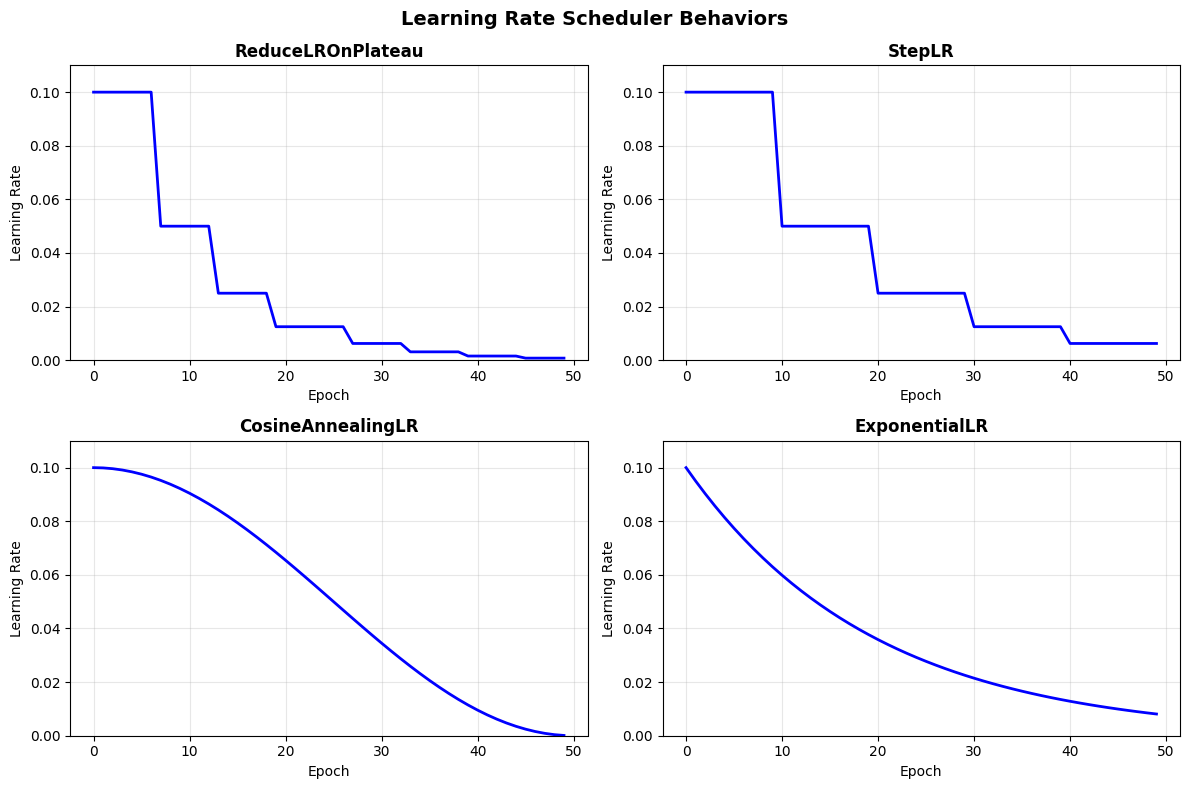

In [6]:
def demonstrate_lr_schedulers():
    """Demonstrate different LR scheduler behaviors."""
    
    # Create a dummy model and optimizer for demonstration
    dummy_model = nn.Linear(10, 1)
    base_lr = 0.1
    epochs = 50
    
    schedulers_config = {
        'ReduceLROnPlateau': lambda opt: optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode='min', factor=0.5, patience=5
        ),
        'StepLR': lambda opt: optim.lr_scheduler.StepLR(
            opt, step_size=10, gamma=0.5
        ),
        'CosineAnnealingLR': lambda opt: optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=epochs, eta_min=1e-6
        ),
        'ExponentialLR': lambda opt: optim.lr_scheduler.ExponentialLR(
            opt, gamma=0.95
        ),
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    
    for idx, (name, scheduler_fn) in enumerate(schedulers_config.items()):
        optimizer = optim.SGD(dummy_model.parameters(), lr=base_lr)
        scheduler = scheduler_fn(optimizer)
        
        lrs = []
        for epoch in range(epochs):
            lrs.append(optimizer.param_groups[0]['lr'])
            
            # For ReduceLROnPlateau, simulate a plateauing loss
            if name == 'ReduceLROnPlateau':
                fake_loss = 1.0 if epoch < 20 else 0.5  # Plateau then improve
                scheduler.step(fake_loss)
            else:
                scheduler.step()
        
        axes[idx].plot(lrs, 'b-', linewidth=2)
        axes[idx].set_title(name, fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Epoch')
        axes[idx].set_ylabel('Learning Rate')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_ylim(0, base_lr * 1.1)
    
    plt.suptitle('Learning Rate Scheduler Behaviors', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualize the schedulers
demonstrate_lr_schedulers()

### Complete Training Function

This function combines everything: model training, validation, early stopping, and LR scheduling.

In [7]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
        _, predicted = outputs.max(1)
        total += y_batch.size(0)
        correct += predicted.eq(y_batch).sum().item()
    
    return running_loss / total, 100. * correct / total


def validate(model, val_loader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            running_loss += loss.item() * X_batch.size(0)
            _, predicted = outputs.max(1)
            total += y_batch.size(0)
            correct += predicted.eq(y_batch).sum().item()
    
    return running_loss / total, 100. * correct / total


def train_model(config, train_dataset, val_dataset, max_epochs=50, verbose=True):
    """
    Complete training loop with early stopping and LR scheduling.
    
    Args:
        config: Dict with hyperparameters (lr, l1, l2, dropout, batch_size)
        train_dataset, val_dataset: PyTorch datasets
        max_epochs: Maximum number of epochs
        verbose: Whether to print progress
    
    Returns:
        model: Trained model
        history: Training history dict
    """
    # Extract hyperparameters
    lr = config.get('lr', 0.001)
    l1 = config.get('l1', 64)
    l2 = config.get('l2', 32)
    dropout = config.get('dropout', 0.2)
    batch_size = config.get('batch_size', 32)
    
    # Create data loaders
    train_loader, val_loader = get_data_loaders(train_dataset, val_dataset, batch_size)
    
    # Initialize model, criterion, optimizer
    model = ConfigurableMLP(input_size=20, l1=l1, l2=l2, dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # LR Scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )
    
    # Early Stopping
    early_stopping = EarlyStopping(patience=7, min_delta=0.001)
    
    # Training history
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'lr': []
    }
    
    for epoch in range(max_epochs):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        # Update scheduler
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Record history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        if verbose and epoch % 5 == 0:
            print(f"Epoch {epoch+1:3d}/{max_epochs} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
                  f"LR: {current_lr:.6f}")
        
        # Early stopping check
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            if verbose:
                print(f"\nEarly stopping triggered at epoch {epoch+1}!")
                print(f"Best validation loss: {early_stopping.best_loss:.4f}")
            break
    
    return model, history

In [8]:
# Demo: Train a model with default hyperparameters
demo_config = {
    'lr': 0.01,
    'l1': 64,
    'l2': 32,
    'dropout': 0.2,
    'batch_size': 32
}

print("Training with default configuration...")
print(f"Config: {demo_config}\n")

model, history = train_model(demo_config, train_dataset, val_dataset, max_epochs=30)

Training with default configuration...
Config: {'lr': 0.01, 'l1': 64, 'l2': 32, 'dropout': 0.2, 'batch_size': 32}

Epoch   1/30 | Train Loss: 0.3992 | Train Acc: 83.33% | Val Loss: 0.2358 | Val Acc: 90.75% | LR: 0.010000
Epoch   6/30 | Train Loss: 0.2289 | Train Acc: 91.00% | Val Loss: 0.2054 | Val Acc: 93.00% | LR: 0.010000
Epoch  11/30 | Train Loss: 0.1574 | Train Acc: 94.58% | Val Loss: 0.1585 | Val Acc: 94.25% | LR: 0.005000
Epoch  16/30 | Train Loss: 0.1465 | Train Acc: 94.50% | Val Loss: 0.1498 | Val Acc: 95.75% | LR: 0.005000
Epoch  21/30 | Train Loss: 0.1480 | Train Acc: 95.00% | Val Loss: 0.1539 | Val Acc: 95.75% | LR: 0.002500

Early stopping triggered at epoch 21!
Best validation loss: 0.1433


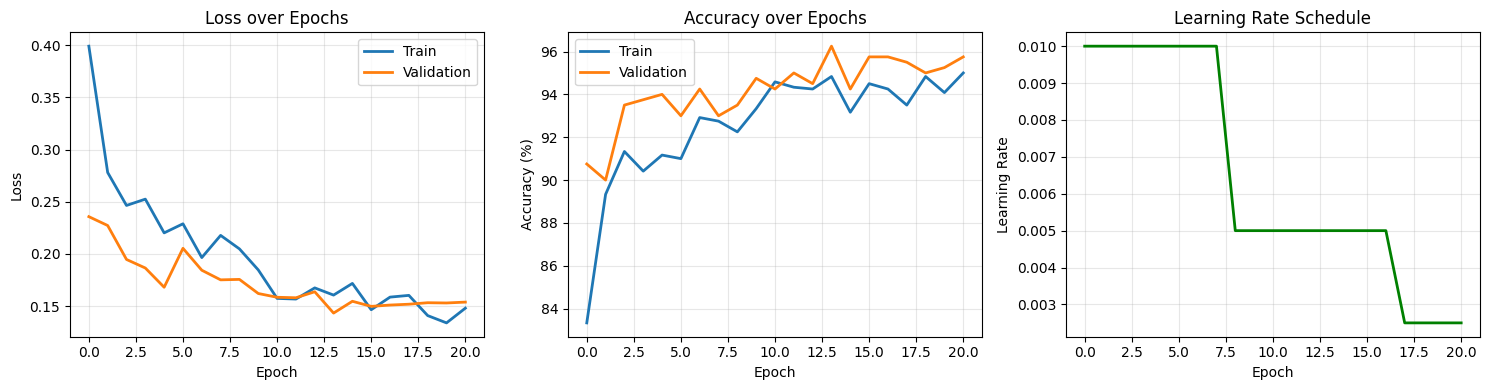

In [9]:
def plot_training_history(history):
    """Plot training history including loss, accuracy, and learning rate."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Loss
    axes[0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0].plot(history['val_loss'], label='Validation', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss over Epochs')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(history['train_acc'], label='Train', linewidth=2)
    axes[1].plot(history['val_acc'], label='Validation', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy over Epochs')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Learning Rate
    axes[2].plot(history['lr'], 'g-', linewidth=2)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate')
    axes[2].set_title('Learning Rate Schedule')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

---

## 5. Strategy 1: Independent Optuna Search

### Optuna's "Define-by-Run" Philosophy

Optuna uses a **define-by-run** approach where the search space is defined dynamically within the objective function. This enables:

- **Conditional hyperparameters**: Different parameters based on previous choices
- **Dynamic search spaces**: The space can change based on trial results
- **Pythonic syntax**: No special configuration language needed

#### Key Optuna Concepts:

| Concept | Description |
|---------|-------------|
| `Trial` | A single experiment with a specific hyperparameter configuration |
| `Study` | A collection of trials optimizing a single objective |
| `Pruning` | Early termination of unpromising trials to save compute |

In [10]:
def optuna_objective(trial):
    """
    Optuna objective function for hyperparameter optimization.
    
    The search space is defined dynamically using trial.suggest_* methods.
    """
    # Define hyperparameter search space
    config = {
        'lr': trial.suggest_float('lr', 1e-5, 1e-1, log=True),
        'l1': trial.suggest_int('l1', 16, 128, step=16),
        'l2': trial.suggest_int('l2', 8, 64, step=8),
        'dropout': trial.suggest_float('dropout', 0.0, 0.5, step=0.1),
        'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64]),
    }
    
    # Create data loaders
    train_loader, val_loader = get_data_loaders(
        train_dataset, val_dataset, config['batch_size']
    )
    
    # Initialize model
    model = ConfigurableMLP(
        input_size=20,
        l1=config['l1'],
        l2=config['l2'],
        dropout=config['dropout']
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    
    # Training loop with pruning
    n_epochs = 20
    
    for epoch in range(n_epochs):
        # Train
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        
        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        # Report to Optuna for pruning decisions
        trial.report(val_acc, epoch)
        
        # Check if trial should be pruned
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return val_acc

In [11]:
# Create and run the Optuna study
print("Starting Optuna hyperparameter search...\n")

# Create study with MedianPruner for early stopping of bad trials
study = optuna.create_study(
    direction='maximize',  # Maximize accuracy
    pruner=optuna.pruners.MedianPruner(n_startup_trials=2, n_warmup_steps=5),
    study_name='mlp_optimization'
)

# Run optimization
study.optimize(
    optuna_objective, 
    n_trials=10,  # Number of trials to run
    show_progress_bar=True
)

print("\n" + "="*60)
print("OPTUNA STUDY COMPLETE")
print("="*60)

[I 2026-04-28 18:02:57,132] A new study created in memory with name: mlp_optimization


Starting Optuna hyperparameter search...



  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-04-28 18:02:57,506] Trial 0 finished with value: 96.0 and parameters: {'lr': 0.014446357712120099, 'l1': 128, 'l2': 56, 'dropout': 0.0, 'batch_size': 64}. Best is trial 0 with value: 96.0.
[I 2026-04-28 18:02:58,830] Trial 1 finished with value: 82.25 and parameters: {'lr': 1.2852212482929867e-05, 'l1': 128, 'l2': 56, 'dropout': 0.30000000000000004, 'batch_size': 16}. Best is trial 0 with value: 96.0.
[I 2026-04-28 18:02:59,321] Trial 2 pruned. 
[I 2026-04-28 18:03:00,733] Trial 3 finished with value: 93.25 and parameters: {'lr': 0.0012026942279718812, 'l1': 16, 'l2': 64, 'dropout': 0.5, 'batch_size': 16}. Best is trial 0 with value: 96.0.
[I 2026-04-28 18:03:01,948] Trial 4 finished with value: 94.25 and parameters: {'lr': 0.00032186238978843353, 'l1': 64, 'l2': 64, 'dropout': 0.2, 'batch_size': 16}. Best is trial 0 with value: 96.0.
[I 2026-04-28 18:03:03,170] Trial 5 finished with value: 91.75 and parameters: {'lr': 0.018028920535548162, 'l1': 64, 'l2': 64, 'dropout': 0.3000

In [12]:
# Analyze Optuna results
print(f"Best trial accuracy: {study.best_trial.value:.2f}%")
print(f"\nBest hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

# Trial statistics
pruned_trials = len([t for t in study.trials if t.state == TrialState.PRUNED])
complete_trials = len([t for t in study.trials if t.state == TrialState.COMPLETE])
print(f"\nTrial statistics:")
print(f"  Completed: {complete_trials}")
print(f"  Pruned: {pruned_trials}")

Best trial accuracy: 96.00%

Best hyperparameters:
  lr: 0.014446357712120099
  l1: 128
  l2: 56
  dropout: 0.0
  batch_size: 64

Trial statistics:
  Completed: 5
  Pruned: 5


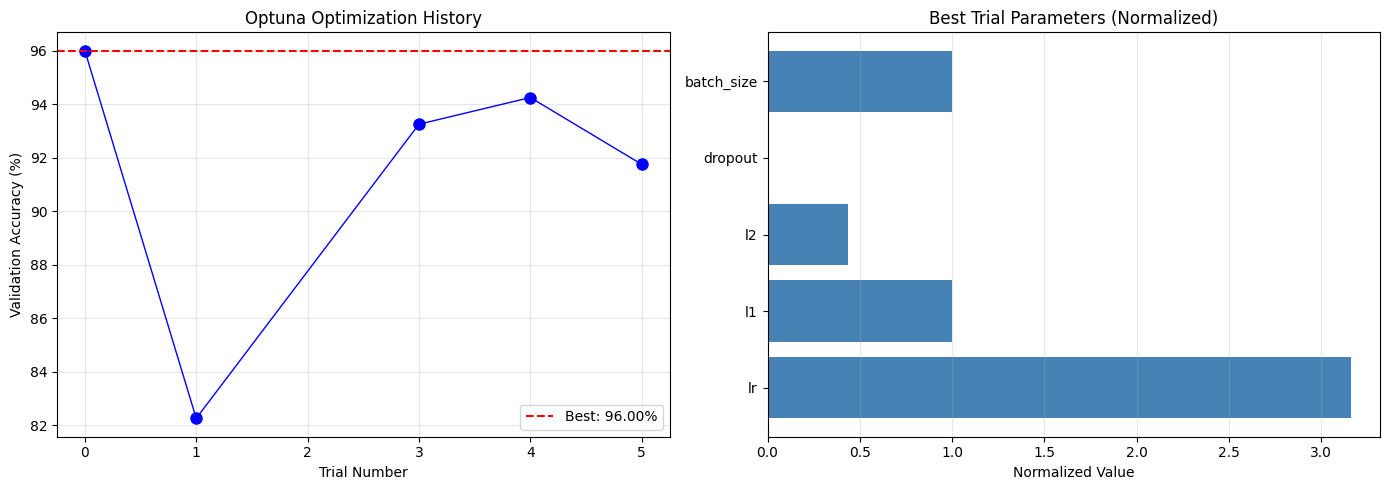

In [13]:
# Visualize Optuna results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Optimization history
trial_numbers = [t.number for t in study.trials if t.state == TrialState.COMPLETE]
trial_values = [t.value for t in study.trials if t.state == TrialState.COMPLETE]

axes[0].plot(trial_numbers, trial_values, 'bo-', markersize=8, linewidth=1)
axes[0].axhline(y=study.best_trial.value, color='r', linestyle='--', label=f'Best: {study.best_trial.value:.2f}%')
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('Validation Accuracy (%)')
axes[0].set_title('Optuna Optimization History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Parameter importance (simple bar chart of best params)
params = list(study.best_trial.params.keys())
# Normalize parameter values for visualization
param_values = []
for p in params:
    val = study.best_trial.params[p]
    if p == 'lr':
        param_values.append(np.log10(val) + 5)  # Normalize log scale
    elif p == 'batch_size':
        param_values.append(val / 64)  # Normalize
    elif p == 'dropout':
        param_values.append(val * 2)  # Scale up
    else:
        param_values.append(val / 128)  # Normalize layer sizes

axes[1].barh(params, param_values, color='steelblue')
axes[1].set_xlabel('Normalized Value')
axes[1].set_title('Best Trial Parameters (Normalized)')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

---

## 6. Strategy 2: Independent Ray Tune Search

### Ray Tune's Scalable Approach

Ray Tune focuses on **scaling** experiments across:
- Multiple CPUs/GPUs on a single machine
- Distributed clusters of machines
- Cloud resources (AWS, GCP, Azure)

> **Note**: This notebook uses **Ray 2.x API**. The API has changed significantly from Ray 1.x. Key changes include:
> - Use `tune.report(metrics={...})` instead of `ray.train.report({...})`  
> - Import `RunConfig` from `ray.tune` (not `ray.train`) when using with Tuner
> - The `verbose` parameter is deprecated in `RunConfig`

#### Key Ray Tune Concepts:

| Concept | Description |
|---------|-------------|
| `Trainable` | A function or class that trains a model with given config |
| `Tuner` | Orchestrates the hyperparameter search |
| `ASHAScheduler` | Aggressive early stopping of bad trials |
| `tune.report()` | Reports metrics back to Ray for scheduling decisions |

In [14]:
def ray_trainable(config):
    """
    Ray Tune trainable function.
    
    Accepts a config dictionary and reports metrics back to Ray.
    """
    # Recreate datasets inside the trainable (Ray runs this in separate processes)
    train_ds, val_ds, _ = create_toy_dataset()
    
    # Create data loaders
    train_loader, val_loader = get_data_loaders(
        train_ds, val_ds, int(config['batch_size'])
    )
    
    # Initialize model
    model = ConfigurableMLP(
        input_size=20,
        l1=int(config['l1']),
        l2=int(config['l2']),
        dropout=config['dropout']
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    
    # Training loop
    n_epochs = 20
    
    for epoch in range(n_epochs):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        # Report metrics to Ray Tune (Ray 2.x API)
        # Use tune.report(metrics={...}) instead of ray.train.report()
        tune.report(metrics={
            'loss': val_loss,
            'accuracy': val_acc,
            'train_loss': train_loss,
            'train_accuracy': train_acc,
            'epoch': epoch
        })

In [15]:
# Define the search space for Ray Tune
ray_search_space = {
    'lr': tune.loguniform(1e-5, 1e-1),
    'l1': tune.choice([16, 32, 64, 128]),
    'l2': tune.choice([8, 16, 32, 64]),
    'dropout': tune.uniform(0.0, 0.5),
    'batch_size': tune.choice([16, 32, 64]),
}

# ASHA Scheduler for aggressive early stopping
# This is Ray's native pruning mechanism
# Note: Don't set metric/mode here - they're set in TuneConfig
asha_scheduler = ASHAScheduler(
    max_t=20,  # Max epochs
    grace_period=3,  # Minimum epochs before pruning
    reduction_factor=2  # How aggressively to prune
)

print("Ray Tune Search Space:")
for key, value in ray_search_space.items():
    print(f"  {key}: {value}")

Ray Tune Search Space:
  lr: <ray.tune.search.sample.Float object at 0x7b8880134d10>
  l1: <ray.tune.search.sample.Categorical object at 0x7b8880134710>
  l2: <ray.tune.search.sample.Categorical object at 0x7b88801357f0>
  dropout: <ray.tune.search.sample.Float object at 0x7b888013ccb0>
  batch_size: <ray.tune.search.sample.Categorical object at 0x7b888013d070>


In [16]:
# Initialize Ray (if not already initialized)
if not ray.is_initialized():
    ray.init(ignore_reinit_error=True, num_cpus=2)

print("Starting Ray Tune hyperparameter search...\n")

# Create the Tuner (Ray 2.x API)
# Note: Use RunConfig from ray.tune, not ray.train
tuner = tune.Tuner(
    tune.with_resources(
        ray_trainable,
        resources={'cpu': 1, 'gpu': 0.5 if torch.cuda.is_available() else 0}
    ),
    param_space=ray_search_space,
    tune_config=tune.TuneConfig(
        metric='accuracy',
        mode='max',
        scheduler=asha_scheduler,
        num_samples=10,  # Number of trials
    ),
    run_config=RunConfig(
        name='ray_tune_mlp',
    )
)

# Run the experiment
results = tuner.fit()

print("\n" + "="*60)
print("RAY TUNE SEARCH COMPLETE")
print("="*60)

2026-04-28 18:03:39,042	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/vscode/ray_results/ray_tune_mlp' in 0.0113s.
2026-04-28 18:03:39,045	INFO tune.py:1041 -- Total run time: 30.08 seconds (30.04 seconds for the tuning loop).



RAY TUNE SEARCH COMPLETE


In [17]:
# Analyze Ray Tune results
best_result = results.get_best_result(metric='accuracy', mode='max')

print(f"Best trial accuracy: {best_result.metrics['accuracy']:.2f}%")
print(f"\nBest hyperparameters:")
for key, value in best_result.config.items():
    print(f"  {key}: {value}")

# Get results dataframe
results_df = results.get_dataframe()
print(f"\nTotal trials run: {len(results_df)}")

Best trial accuracy: 95.00%

Best hyperparameters:
  lr: 0.013826232179369865
  l1: 64
  l2: 64
  dropout: 0.2571172192068058
  batch_size: 16

Total trials run: 10


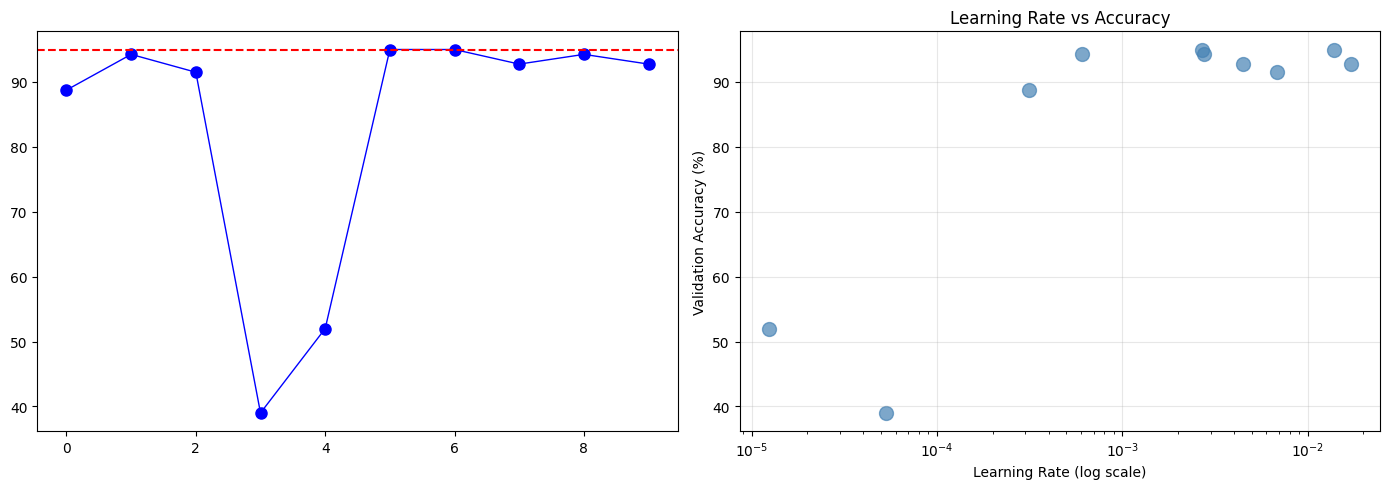

In [ ]:
# Visualize Ray Tune results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy distribution
accuracies = results_df['accuracy'].dropna()
trials = list(range(len(accuracies)))
axes[0].plot(trials, accuracies, 'bo-', markersize=8, linewidth=1)
axes[0].axhline(y=best_result.metrics['accuracy'],color='r', linestyle='--',
                label=f'Best: {best_result.metrics["accuracy"]:.2f}%')

# Plot 2: Learning rate vs accuracy scatter
if 'config/lr' in results_df.columns:
    axes[1].scatter(results_df['config/lr'], results_df['accuracy'], 
                   alpha=0.7, s=100, c='steelblue')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Learning Rate (log scale)')
    axes[1].set_ylabel('Validation Accuracy (%)')
    axes[1].set_title('Learning Rate vs Accuracy')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---

## 7. Strategy 3: Ray Tune + Optuna (The Hybrid)

### The Best of Both Worlds

Combining Ray Tune and Optuna gives you:

| From Ray | From Optuna |
|----------|------------|
| Distributed execution | Sophisticated search algorithms (TPE, CMA-ES) |
| Resource management | Conditional search spaces |
| Fault tolerance | Define-by-run flexibility |
| ASHA scheduling | Pruning strategies |

This is done using `OptunaSearch` as the search algorithm within Ray Tune.

In [19]:
from ray.tune.search import ConcurrencyLimiter

# Create Optuna search algorithm for Ray Tune
optuna_search = OptunaSearch(
    metric='accuracy',
    mode='max',
)

# Limit concurrency to avoid overwhelming resources
# This is important when using Optuna's sequential sampling
algo = ConcurrencyLimiter(optuna_search, max_concurrent=2)

print("Hybrid search algorithm configured:")
print("  - Search: OptunaSearch (TPE sampler)")
print("  - Scheduler: ASHA (from Ray)")
print("  - Max concurrent trials: 2")

Hybrid search algorithm configured:
  - Search: OptunaSearch (TPE sampler)
  - Scheduler: ASHA (from Ray)
  - Max concurrent trials: 2


In [ ]:
print("Starting Hybrid Ray+Optuna hyperparameter search...\n")

# Create the Tuner with Optuna search (Ray 2.x API)
hybrid_tuner = tune.Tuner(
    tune.with_resources(
        ray_trainable,
        resources={'cpu': 1, 'gpu': 0.5 if torch.cuda.is_available() else 0}
    ),
    param_space=ray_search_space,  # Same search space as before
    tune_config=tune.TuneConfig(
        metric='accuracy',
        mode='max',
        # scheduler=hybrid_asha_scheduler,  # Don't use scheduler, use search_alg
        search_alg=algo,  # Use Optuna for search!
        num_samples=10,
    ),
    run_config=RunConfig(
        name='hybrid_ray_optuna',
    )
)

# Run the hybrid experiment
hybrid_results = hybrid_tuner.fit()

print("\n" + "="*60)
print("HYBRID RAY+OPTUNA SEARCH COMPLETE")
print("="*60)

2026-04-28 18:04:17,222	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/vscode/ray_results/hybrid_ray_optuna' in 0.0111s.
2026-04-28 18:04:17,225	INFO tune.py:1041 -- Total run time: 37.60 seconds (37.57 seconds for the tuning loop).



HYBRID RAY+OPTUNA SEARCH COMPLETE


In [21]:
# Analyze hybrid results
hybrid_best = hybrid_results.get_best_result(metric='accuracy', mode='max')

print(f"Best trial accuracy: {hybrid_best.metrics['accuracy']:.2f}%")
print(f"\nBest hyperparameters:")
for key, value in hybrid_best.config.items():
    print(f"  {key}: {value}")

Best trial accuracy: 95.75%

Best hyperparameters:
  lr: 0.015424226457675654
  l1: 64
  l2: 8
  dropout: 0.27692750532023247
  batch_size: 64


---

## 8. Visualization with Weights & Biases (WandB)

### Why WandB?

WandB provides:
- **Automatic experiment tracking**: Logs metrics, hyperparameters, and artifacts
- **Interactive dashboards**: Compare runs visually
- **Parallel coordinates plots**: See hyperparameter correlations
- **Team collaboration**: Share experiments easily

### Integration Options:

| Framework | Integration Method |
|-----------|-------------------|
| PyTorch (standalone) | Manual `wandb.log()` calls |
| Optuna | `WandbCallback` or manual logging |
| Ray Tune | `WandbLoggerCallback` |

In [22]:
def train_with_wandb(config, project_name='hyperopt-demo'):
    """
    Training function with WandB integration.
    
    This demonstrates manual WandB logging for any PyTorch training.
    """
    # Initialize WandB run
    run = wandb.init(
        project=project_name,
        config=config,
        reinit=True  # Allow multiple runs in same session
    )
    
    # Create data loaders
    train_loader, val_loader = get_data_loaders(
        train_dataset, val_dataset, config['batch_size']
    )
    
    # Initialize model
    model = ConfigurableMLP(
        input_size=20,
        l1=config['l1'],
        l2=config['l2'],
        dropout=config['dropout']
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    early_stopping = EarlyStopping(patience=7)
    
    # Watch model gradients (optional but useful)
    wandb.watch(model, log='gradients', log_freq=100)
    
    n_epochs = 30
    
    for epoch in range(n_epochs):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        # Update scheduler
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Log metrics to WandB
        wandb.log({
            'epoch': epoch,
            'train/loss': train_loss,
            'train/accuracy': train_acc,
            'val/loss': val_loss,
            'val/accuracy': val_acc,
            'learning_rate': current_lr,
        })
        
        # Early stopping
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Log final metrics
    wandb.summary['best_val_loss'] = early_stopping.best_loss
    wandb.summary['best_val_accuracy'] = val_acc
    
    # Finish the run
    wandb.finish()
    
    return model

In [23]:
# Example: Train with WandB logging
# Note: You need to run `wandb login` first or set WANDB_API_KEY

wandb_config = {
    'lr': 0.01,
    'l1': 64,
    'l2': 32,
    'dropout': 0.2,
    'batch_size': 32
}

# Uncomment below to run with WandB (requires login)
# train_with_wandb(wandb_config, project_name='hyperopt-demo')

print("WandB training function ready!")
print("To use: Uncomment the line above after running 'wandb login'")

WandB training function ready!
To use: Uncomment the line above after running 'wandb login'


### Ray Tune + WandB Integration

Ray Tune has built-in WandB support via `WandbLoggerCallback`:

In [24]:
from ray.tune.logger import TBXLoggerCallback

# Example: Ray Tune with WandB logging
# Note: For Ray 2.x, WandB integration has changed.
# The WandbLoggerCallback is now in ray.tune.logger.wandb
# Uncomment to run (requires wandb login)

'''
# For WandB integration in Ray 2.x:
# pip install wandb
# from ray.tune.logger.wandb import WandbLoggerCallback

wandb_tuner = tune.Tuner(
    tune.with_resources(ray_trainable, resources={'cpu': 1}),
    param_space=ray_search_space,
    tune_config=tune.TuneConfig(
        metric='accuracy',
        mode='max',
        num_samples=5,
    ),
    run_config=RunConfig(
        name='ray_wandb_demo',
        # For TensorBoard logging (built-in):
        # callbacks=[TBXLoggerCallback()]
        # For WandB, use: callbacks=[WandbLoggerCallback(project='ray-tune-demo')]
    )
)

wandb_results = wandb_tuner.fit()
'''

print("Ray Tune + WandB integration example ready!")
print("Uncomment the code block above after running 'wandb login'")
print("Note: Check Ray documentation for the latest WandB integration API")

Ray Tune + WandB integration example ready!
Uncomment the code block above after running 'wandb login'
Note: Check Ray documentation for the latest WandB integration API


### Viewing WandB Dashboard

After running experiments with WandB, visit [wandb.ai](https://wandb.ai) to:

1. **View Parallel Coordinates**: See how different hyperparameters correlate with performance
2. **Compare Runs**: Side-by-side comparison of different configurations
3. **Filter by Metrics**: Find your best runs quickly
4. **Export Data**: Download results for further analysis

![WandB Dashboard Example](https://wandb.ai/site/images/frontpage/hero.png)

---

## 9. Comparison of All Strategies

In [25]:
# Compare results from all three strategies
print("="*70)
print("COMPARISON OF HYPERPARAMETER OPTIMIZATION STRATEGIES")
print("="*70)

comparison_data = [
    ('Optuna (Standalone)', study.best_trial.value, study.best_trial.params),
    ('Ray Tune (Standalone)', best_result.metrics['accuracy'], best_result.config),
    ('Ray + Optuna (Hybrid)', hybrid_best.metrics['accuracy'], hybrid_best.config),
]

for name, accuracy, params in comparison_data:
    print(f"\n{name}:")
    print(f"  Best Accuracy: {accuracy:.2f}%")
    print(f"  Parameters:")
    for k, v in params.items():
        if isinstance(v, float):
            print(f"    {k}: {v:.6f}")
        else:
            print(f"    {k}: {v}")

COMPARISON OF HYPERPARAMETER OPTIMIZATION STRATEGIES

Optuna (Standalone):
  Best Accuracy: 96.00%
  Parameters:
    lr: 0.014446
    l1: 128
    l2: 56
    dropout: 0.000000
    batch_size: 64

Ray Tune (Standalone):
  Best Accuracy: 95.00%
  Parameters:
    lr: 0.013826
    l1: 64
    l2: 64
    dropout: 0.257117
    batch_size: 16

Ray + Optuna (Hybrid):
  Best Accuracy: 95.75%
  Parameters:
    lr: 0.015424
    l1: 64
    l2: 8
    dropout: 0.276928
    batch_size: 64


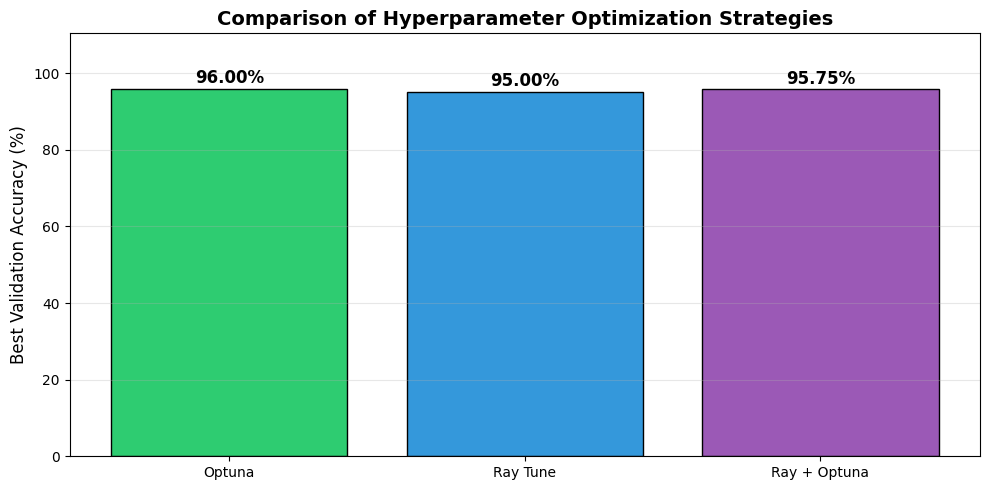

In [26]:
# Visualize comparison
strategies = ['Optuna', 'Ray Tune', 'Ray + Optuna']
accuracies = [
    study.best_trial.value,
    best_result.metrics['accuracy'],
    hybrid_best.metrics['accuracy']
]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(strategies, accuracies, color=['#2ecc71', '#3498db', '#9b59b6'], edgecolor='black')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Best Validation Accuracy (%)', fontsize=12)
ax.set_title('Comparison of Hyperparameter Optimization Strategies', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(accuracies) * 1.15)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---

## 10. Conclusion and Best Practices

### Summary

| Tool | Strengths | Best For |
|------|-----------|----------|
| **Optuna** | Flexibility, define-by-run, conditional spaces | Complex search spaces, single-machine experiments |
| **Ray Tune** | Scalability, resource management, fault tolerance | Distributed training, multi-GPU experiments |
| **Ray + Optuna** | Combined benefits | Production workloads requiring both flexibility and scale |
| **WandB** | Visualization, collaboration, experiment tracking | All experiments—always use for visibility |

### Best Practices

1. **Always use Early Stopping**
   - Custom implementation or ASHA scheduler
   - Saves significant compute on bad configurations

2. **Always use LR Scheduling**
   - `ReduceLROnPlateau` is a safe default
   - `OneCycleLR` for faster convergence (if you know the total steps)

3. **Start with Fewer Trials, Then Scale**
   - Run 10-20 trials first to understand the search space
   - Then run 50-100 trials for final optimization

4. **Use Log Scale for Learning Rate**
   - LR typically varies over orders of magnitude
   - `tune.loguniform(1e-5, 1e-1)` or `trial.suggest_float('lr', 1e-5, 1e-1, log=True)`

5. **Track Everything with WandB**
   - Metrics, hyperparameters, artifacts
   - Makes debugging and comparison easy

6. **Set Random Seeds**
   - For reproducibility across trials
   - But remember: different hardware may give different results

In [27]:
# Clean up Ray
ray.shutdown()
print("Notebook complete! Ray has been shut down.")

Notebook complete! Ray has been shut down.


---

## 📚 Additional Resources

### Documentation
- [PyTorch Documentation](https://pytorch.org/docs/stable/index.html)
- [Optuna Documentation](https://optuna.readthedocs.io/)
- [Ray Tune Documentation](https://docs.ray.io/en/latest/tune/index.html)
- [Weights & Biases Documentation](https://docs.wandb.ai/)

### Tutorials
- [Optuna: A Hyperparameter Optimization Framework](https://optuna.org/)
- [Ray Tune: Scalable Hyperparameter Tuning](https://docs.ray.io/en/latest/tune/getting-started.html)
- [WandB: Experiment Tracking](https://wandb.ai/site/tutorials)

### Papers
- [Hyperparameter Optimization: A Survey](https://arxiv.org/abs/1912.01703)
- [Optuna: A Next-generation Hyperparameter Optimization Framework](https://arxiv.org/abs/1907.10902)
- [ASHA: Asynchronous Successive Halving](https://arxiv.org/abs/1810.05934)